In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 


In [3]:
file_path=r"C:\Users\muham\Downloads\students_logistic.csv"
df=pd.read_csv(file_path).drop(columns=['Unnamed: 0'])
df.head()



,study_hours,pass
0,1.0,0
1,1.5,0
2,2.0,0
3,2.5,0
4,3.0,0


In [4]:
X=df[['study_hours']].values

X.shape

(19, 1)

In [5]:
Y=df[['pass']]
Y.shape

(19, 1)

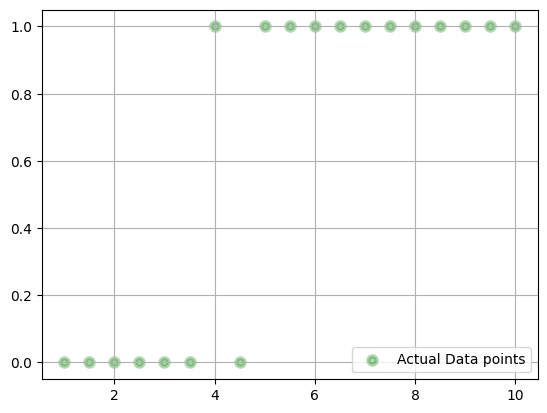

In [6]:

plt.scatter(X,Y,color='green',linewidths=3,alpha=0.3,label="Actual Data points")
plt.grid()
plt.legend()
plt.show()

#### first we see that this problem can be solved in linear regression


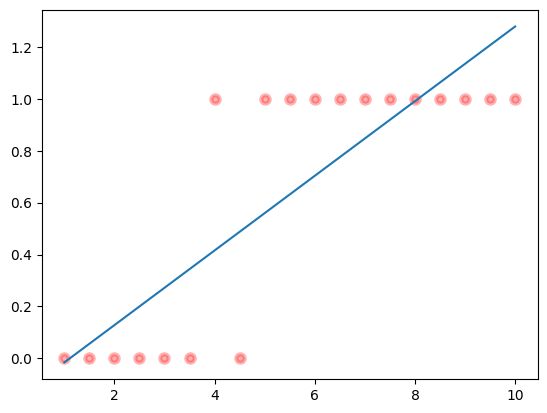

In [7]:
from sklearn.linear_model import LinearRegression
model1=LinearRegression()
model1.fit(X,Y)
pred1=model1.predict(X)
plt.scatter(X,Y,linewidths=3,color='red',alpha= 0.3)
plt.plot(X,pred1)


In [8]:
X.flatten()

array([ 1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,  5.5,  6. ,
        6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. ])

## as a result we cannot solve this type of problem with linear regression becz the this line dose not represnt the data correctly and give the result is greater then 100% .therefore the line doesnot sqush .for squshing we can used the function sigmoid function.this function give the probiblity between 0 and 1 fisrt we can implemnt it in manully then sciket learn libraray
## if the probiblity the less then 0.5 then class 0 other wiase 1.lets solve this problem manully

In [9]:
def sigmoid(X,w,b):
    z=w * X + b
    return 1/(1+ np.exp(-z))

In [10]:
def cost(X,Y,w,b):
    e=1e-9
    Y_pred=sigmoid(X,w,b)
    loss=-np.mean(Y * np.log(Y_pred + e)+(1-Y) * np.log(1-Y_pred + e))
    return loss

In [11]:
def gradient(X,Y,w,b):
    Y_pred=sigmoid(X,w,b)
    error=Y_pred - Y
    gw=np.mean(error * X)
    gb=np.mean(error)
    return gw,gb

In [12]:
w=0
b=0
alpha=0.3
history=[]
for i in range(1,1000):
    gw,gb=gradient(X,Y,w,b)
    w-= alpha * gw
    b-=alpha * gb
    loss=cost(X,Y,w,b)
    history.append(loss)
    print(f"EPochs:-------  {i}------ cost {loss}") 

EPochs:-------  1------ cost 0.6348793713268076
EPochs:-------  2------ cost 0.5077096780947662
EPochs:-------  3------ cost 0.48655902410489726
EPochs:-------  4------ cost 0.4808282800571958
EPochs:-------  5------ cost 0.47541172781901975
EPochs:-------  6------ cost 0.4701547455639967
EPochs:-------  7------ cost 0.465023154628248
EPochs:-------  8------ cost 0.46001019858738773
EPochs:-------  9------ cost 0.4551125267919666
EPochs:-------  10------ cost 0.45032730286295286
EPochs:-------  11------ cost 0.44565178791358706
EPochs:-------  12------ cost 0.44108328902725025
EPochs:-------  13------ cost 0.4366191548717197
EPochs:-------  14------ cost 0.4322567770903249
EPochs:-------  15------ cost 0.4279935919648389
EPochs:-------  16------ cost 0.4238270819684904
EPochs:-------  17------ cost 0.4197547770527748
EPochs:-------  18------ cost 0.4157742557175668
EPochs:-------  19------ cost 0.41188314586389213
EPochs:-------  20------ cost 0.4080791254494169
EPochs:-------  21-----

In [13]:
history
epochs = list(range(1, 1000))


In [16]:
Y_pred=sigmoid(X,w,b)
Y_pred

array([[0.00425773],
       [0.0099856 ],
       [0.02323924],
       [0.05313988],
       [0.11690744],
       [0.23796453],
       [0.42416579],
       [0.63471093],
       [0.80386951],
       [0.90626268],
       [0.95799319],
       [0.98175024],
       [0.99218109],
       [0.9966703 ],
       [0.99858571],
       [0.99939995],
       [0.99974553],
       [0.9998921 ],
       [0.99995426]])

In [17]:
Y

,pass
0,0
1,0
2,0
3,0
4,0
5,0
6,1
7,0
8,1
9,1


In [19]:
threshold = np.where(sigmoid(X, w, b) > 0.5, 1, 0)
threshold

array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1]])

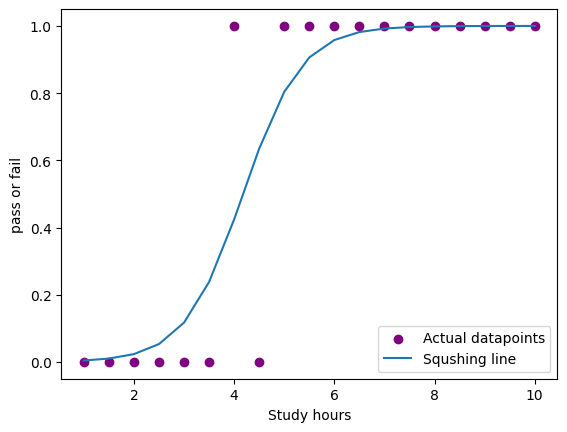

In [ ]:
plt.scatter(X,Y,color='purple',label="Actual datapoints")
Y_pred=sigmoid(X,w,b)
plt.plot(X,Y_pred,label="Squshing line")
plt.xlabel("Study hours")
plt.ylabel("pass or fail")
plt.legend()
